# Content-Based Movie Recommender System
## Mini-project 1: ISA Development

This notebook performs exploratory data analysis (EDA) and preprocessing on the TMDB movie dataset to build a content-based movie recommender system. We analyze movie metadata including genres, cast, crew, keywords, and plot overviews to understand the data before building our recommendation engine.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Data Loading

In [2]:
metadata = pd.read_csv('../data/raw/movies_metadata.csv', low_memory=False)
credits = pd.read_csv('../data/raw/credits.csv')
keywords = pd.read_csv('../data/raw/keywords.csv')
links_small = pd.read_csv('../data/raw/links_small.csv')
ratings = pd.read_csv('../data/raw/ratings_small.csv')

## 2. Exploratory Data Analysis (EDA)

### 2.1 Dataset Overview

In [3]:
print(f"Movies Metadata: {metadata.shape}")
print(f"Credits: {credits.shape}")
print(f"Keywords: {keywords.shape}")
print(f"Links Small: {links_small.shape}")
print(f"Ratings Small: {ratings.shape}")
print("\n--- Movies Metadata Sample ---")
metadata.head(3)

Movies Metadata: (45466, 24)
Credits: (45476, 3)
Keywords: (46419, 2)
Links Small: (9125, 3)
Ratings Small: (100004, 4)

--- Movies Metadata Sample ---


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0


In [4]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  str    
 1   belongs_to_collection  4494 non-null   str    
 2   budget                 45466 non-null  str    
 3   genres                 45466 non-null  str    
 4   homepage               7782 non-null   str    
 5   id                     45466 non-null  str    
 6   imdb_id                45449 non-null  str    
 7   original_language      45455 non-null  str    
 8   original_title         45466 non-null  str    
 9   overview               44512 non-null  str    
 10  popularity             45461 non-null  str    
 11  poster_path            45080 non-null  str    
 12  production_companies   45463 non-null  str    
 13  production_countries   45463 non-null  str    
 14  release_date           45379 non-null  str    
 15  revenue      

In [5]:
metadata.describe()

,revenue,runtime,vote_average,vote_count
count,4.546000e+04,45203.000000,45460.000000,45460.000000
mean,1.120935e+07,94.128199,5.618207,109.897338
std,6.433225e+07,38.407810,1.924216,491.310374
min,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,85.000000,5.000000,3.000000
50%,0.000000e+00,95.000000,6.000000,10.000000
75%,0.000000e+00,107.000000,6.800000,34.000000
max,2.787965e+09,1256.000000,10.000000,14075.000000


### 2.2 Missing Values Analysis

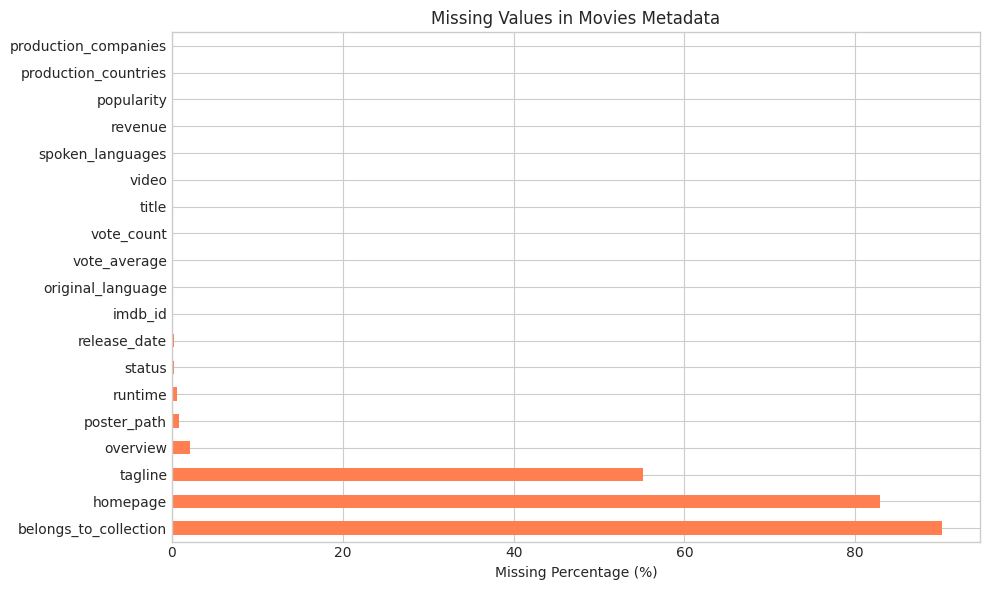


Total rows: 45466

Columns with missing values:
belongs_to_collection    90.115691
homepage                 82.883913
tagline                  55.104914
overview                  2.098271
poster_path               0.848986
runtime                   0.578454
status                    0.191352
release_date              0.191352
imdb_id                   0.037391
original_language         0.024194
vote_average              0.013197
vote_count                0.013197
title                     0.013197
video                     0.013197
spoken_languages          0.013197
revenue                   0.013197
popularity                0.010997
production_countries      0.006598
production_companies      0.006598


In [6]:
# Calculate missing value percentages
missing = metadata.isnull().sum()
missing_pct = (missing / len(metadata) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 6))
missing_pct.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values in Movies Metadata')
plt.tight_layout()
plt.savefig('../reports/figures/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal rows: {len(metadata)}")
print(f"\nColumns with missing values:\n{missing_pct.to_string()}")

### 2.3 Rating Distribution

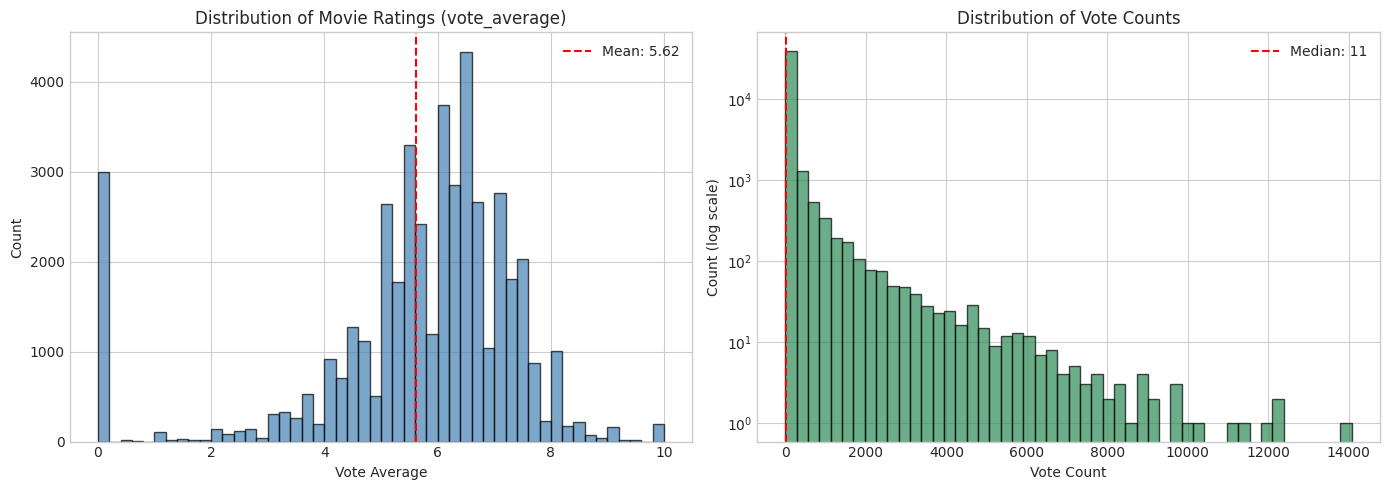

Mean rating: 5.62
Median vote count: 10
Movies with 0 votes: 2899


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vote average distribution
axes[0].hist(metadata['vote_average'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Vote Average')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Movie Ratings (vote_average)')
axes[0].axvline(metadata['vote_average'].mean(), color='red', linestyle='--', label=f"Mean: {metadata['vote_average'].mean():.2f}")
axes[0].legend()

# Vote count distribution (log scale)
vote_counts = metadata['vote_count'].dropna()
vote_counts = vote_counts[vote_counts > 0]
axes[1].hist(vote_counts, bins=50, color='seagreen', edgecolor='black', alpha=0.7, log=True)
axes[1].set_xlabel('Vote Count')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Distribution of Vote Counts')
axes[1].axvline(vote_counts.median(), color='red', linestyle='--', label=f"Median: {vote_counts.median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean rating: {metadata['vote_average'].mean():.2f}")
print(f"Median vote count: {metadata['vote_count'].median():.0f}")
print(f"Movies with 0 votes: {(metadata['vote_count'] == 0).sum()}")

### 2.4 Genre Analysis

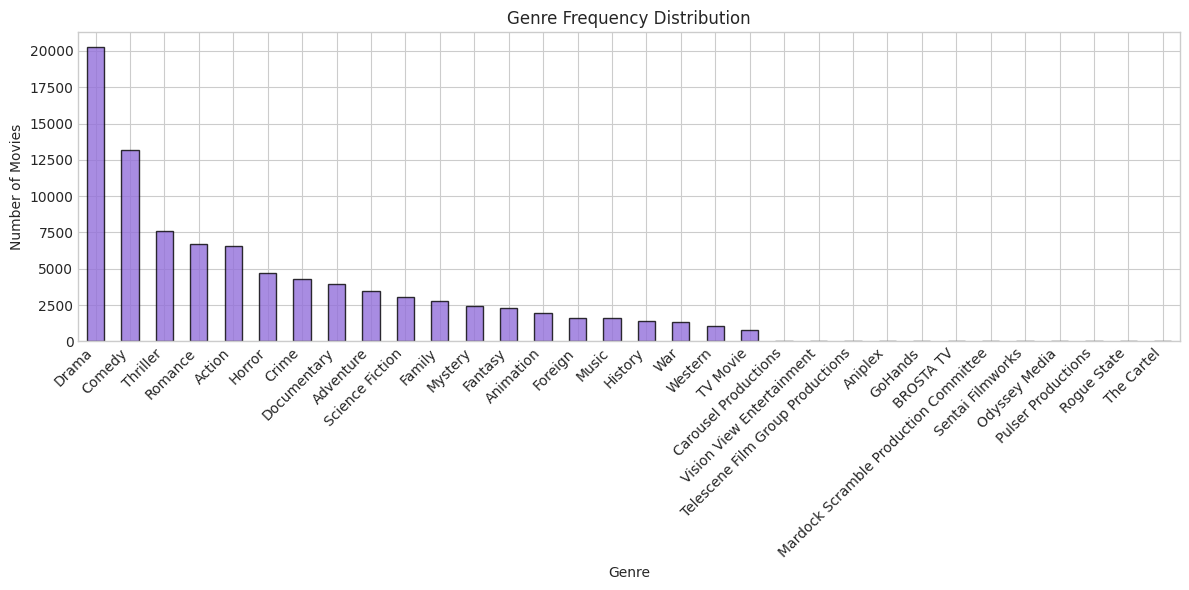

Total unique genres: 32

Top 10 genres:
genres_parsed
Drama              20265
Comedy             13182
Thriller            7624
Romance             6735
Action              6596
Horror              4673
Crime               4307
Documentary         3932
Adventure           3496
Science Fiction     3049


In [8]:
# Parse genres from string representation of list of dicts
metadata['genres_parsed'] = metadata['genres'].fillna('[]').apply(lambda x: [d['name'] for d in literal_eval(x)] if isinstance(x, str) and x.startswith('[') else [])

# Explode genres for frequency analysis
all_genres = metadata['genres_parsed'].explode()
genre_counts = all_genres.value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
genre_counts.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='black', alpha=0.8)
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Movies')
ax.set_title('Genre Frequency Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total unique genres: {genre_counts.shape[0]}")
print(f"\nTop 10 genres:\n{genre_counts.head(10).to_string()}")

### 2.5 Cast and Director Analysis

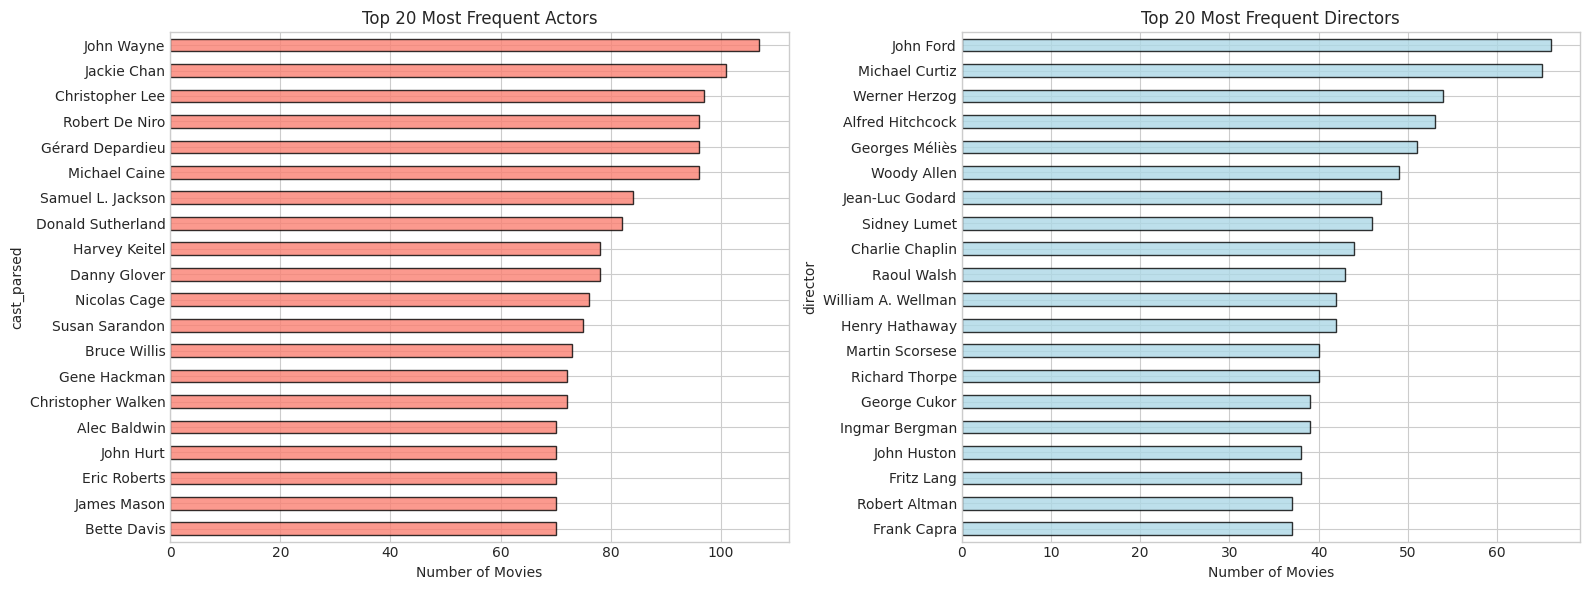

In [9]:
# Parse cast and crew
credits['cast_parsed'] = credits['cast'].apply(lambda x: [d['name'] for d in literal_eval(x)][:5] if isinstance(x, str) else [])
credits['director'] = credits['crew'].apply(lambda x: [d['name'] for d in literal_eval(x) if d['job'] == 'Director'] if isinstance(x, str) else [])
credits['director'] = credits['director'].apply(lambda x: x[0] if len(x) > 0 else np.nan)

# Top actors
all_actors = credits['cast_parsed'].explode()
top_actors = all_actors.value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_actors.plot(kind='barh', ax=axes[0], color='salmon', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Number of Movies')
axes[0].set_title('Top 20 Most Frequent Actors')
axes[0].invert_yaxis()

# Top directors
top_directors = credits['director'].value_counts().head(20)
top_directors.plot(kind='barh', ax=axes[1], color='lightblue', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Number of Movies')
axes[1].set_title('Top 20 Most Frequent Directors')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/cast_director_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.6 Overview Word Cloud

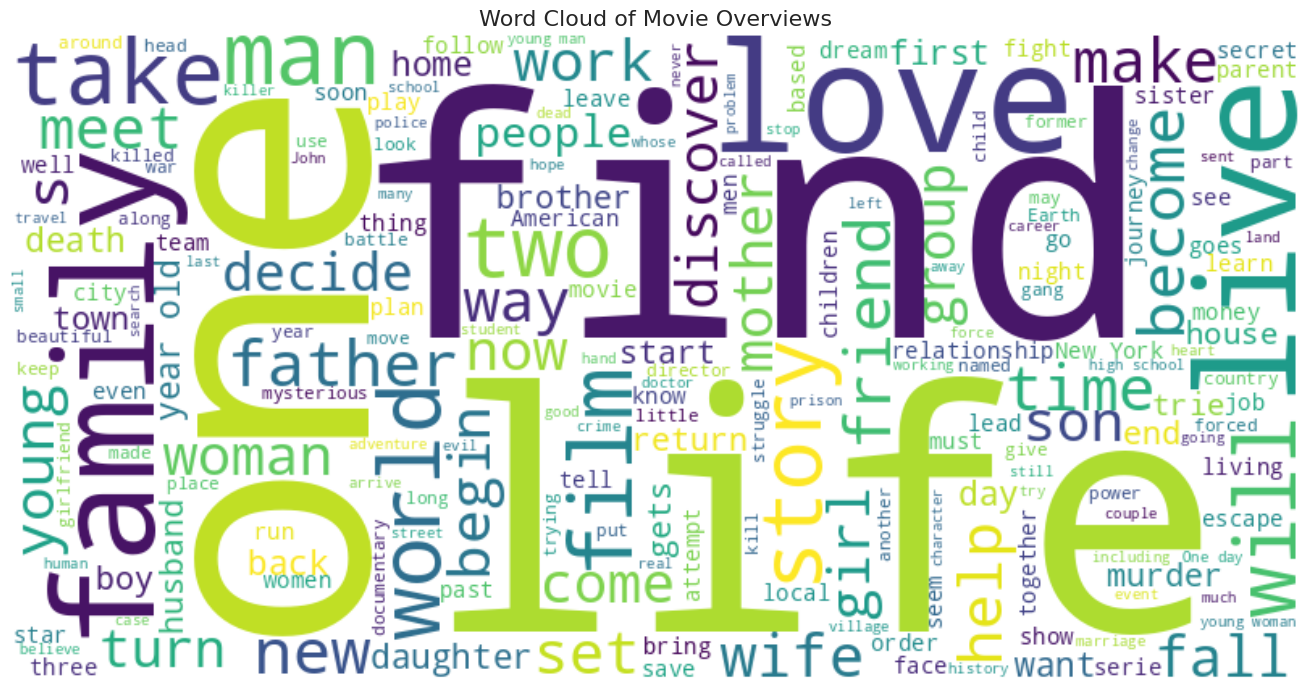

In [10]:
text = ' '.join(metadata['overview'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, max_words=200, background_color='white', colormap='viridis').generate(text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud of Movie Overviews', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/overview_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.7 Correlation Analysis

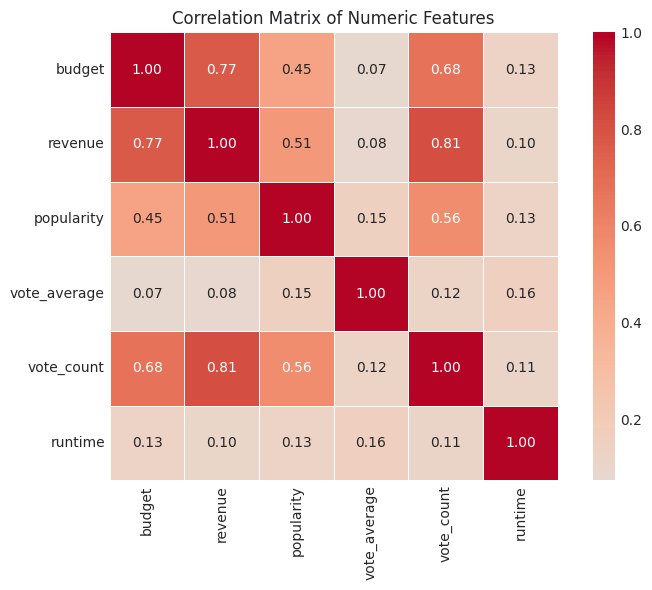

In [11]:
# Convert budget and revenue to numeric
metadata['budget'] = pd.to_numeric(metadata['budget'], errors='coerce')
metadata['revenue'] = pd.to_numeric(metadata['revenue'], errors='coerce')
metadata['popularity'] = pd.to_numeric(metadata['popularity'], errors='coerce')

numeric_cols = ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count', 'runtime']
corr_matrix = metadata[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.8 EDA Summary & Quest Establishment

**Key Findings:**
- The dataset contains ~45,000 movies with metadata including genres, cast, crew, keywords, and plot overviews
- Rating distribution is roughly normal centered around 6.0, with many movies having very few votes
- Drama, Comedy, and Thriller are the most common genres
- There is significant missing data in some columns (homepage, tagline, belongs_to_collection)
- Strong correlation between budget/revenue and vote_count, suggesting popular movies get more votes

**Quest:**
Build a content-based recommender that uses movie metadata (genres, keywords, cast, director) combined with plot overviews to find similar movies. Use TF-IDF vectorization with cosine similarity, enhanced by a weighted rating filter to prioritize quality results.

## 3. Data Preprocessing

In [12]:
# Some rows have date strings in the 'id' column - remove these
metadata = metadata[metadata['id'].apply(lambda x: str(x).isdigit())]

# Convert id to int for merging
metadata['id'] = metadata['id'].astype(int)

# Convert credits and keywords id to int
credits['id'] = credits['id'].astype(int)
keywords['id'] = keywords['id'].astype(int)

# Filter to movies in links_small (smaller subset for faster computation)
links_small = links_small[links_small['tmdbId'].notna()]
links_small['tmdbId'] = links_small['tmdbId'].astype(int)
smd = metadata[metadata['id'].isin(links_small['tmdbId'])]
print(f"Full metadata: {metadata.shape[0]} movies")
print(f"Small subset (links_small): {smd.shape[0]} movies")

Full metadata: 45463 movies
Small subset (links_small): 9099 movies


### 3.1 Parsing JSON-like Columns

In [13]:
# Parse genres for the small dataset
smd['genres'] = smd['genres'].fillna('[]').apply(literal_eval).apply(lambda x: [d['name'] for d in x] if isinstance(x, list) else [])

# Merge keywords
kw = keywords.copy()
kw['keywords'] = kw['keywords'].apply(literal_eval).apply(lambda x: [d['name'] for d in x] if isinstance(x, list) else [])
smd = smd.merge(kw, on='id', how='left')
smd['keywords'] = smd['keywords'].fillna('').apply(lambda x: x if isinstance(x, list) else [])

print(f"Sample genres: {smd['genres'].iloc[0]}")
print(f"Sample keywords: {smd['keywords'].iloc[0]}")

Sample genres: ['Animation', 'Comedy', 'Family']
Sample keywords: ['jealousy', 'toy', 'boy', 'friendship', 'friends', 'rivalry', 'boy next door', 'new toy', 'toy comes to life']


In [14]:
# Merge credits
cred = credits.copy()
cred['cast'] = cred['cast'].apply(literal_eval).apply(lambda x: [d['name'] for d in x][:3] if isinstance(x, list) else [])
cred['director'] = cred['crew'].apply(literal_eval).apply(
    lambda x: next((d['name'] for d in x if d['job'] == 'Director'), np.nan) if isinstance(x, list) else np.nan
)
cred = cred[['id', 'cast', 'director']]

smd = smd.merge(cred, on='id', how='left')
smd['cast'] = smd['cast'].fillna('').apply(lambda x: x if isinstance(x, list) else [])
smd['director'] = smd['director'].fillna('')

print(f"Sample cast: {smd['cast'].iloc[0]}")
print(f"Sample director: {smd['director'].iloc[0]}")
print(f"Dataset shape after merge: {smd.shape}")

Sample cast: ['Tom Hanks', 'Tim Allen', 'Don Rickles']
Sample director: John Lasseter
Dataset shape after merge: (9219, 28)


### 3.2 Handling Missing Values

In [15]:
# Check missing values in key columns
key_cols = ['title', 'overview', 'genres', 'keywords', 'cast', 'director']
for col in key_cols:
    if col in ['genres', 'keywords', 'cast']:
        missing = smd[col].apply(lambda x: len(x) == 0).sum()
    else:
        missing = smd[col].isna().sum() + (smd[col] == '').sum()
    print(f"{col}: {missing} missing ({missing/len(smd)*100:.1f}%)")

# Fill missing overviews with empty string
smd['overview'] = smd['overview'].fillna('')

# Drop rows without a title
smd = smd[smd['title'].notna()]
print(f"\nDataset shape after cleaning: {smd.shape}")

title: 0 missing (0.0%)
overview: 12 missing (0.1%)
genres: 35 missing (0.4%)
keywords: 783 missing (8.5%)
cast: 91 missing (1.0%)
director: 24 missing (0.3%)

Dataset shape after cleaning: (9219, 28)


### 3.3 Text Cleaning and Feature Engineering

In [16]:
def clean_text(text_list):
    """Remove spaces from names to create single tokens (e.g., 'Johnny Depp' -> 'johnnydepp')"""
    if isinstance(text_list, list):
        return [str(x).lower().replace(' ', '') for x in text_list]
    return str(text_list).lower().replace(' ', '')

# Apply cleaning
smd['genres_clean'] = smd['genres'].apply(clean_text)
smd['keywords_clean'] = smd['keywords'].apply(clean_text)
smd['cast_clean'] = smd['cast'].apply(clean_text)
smd['director_clean'] = smd['director'].apply(clean_text)

# Build metadata soup
def create_soup(row):
    """Combine all metadata features into a single string for TF-IDF"""
    genres = ' '.join(row['genres_clean'])
    keywords = ' '.join(row['keywords_clean'])
    cast = ' '.join(row['cast_clean'])
    # Repeat director 3x to give more weight
    director = ' '.join([row['director_clean']] * 3)
    overview = str(row['overview']).lower()
    return f"{overview} {genres} {keywords} {cast} {director}"

smd['soup'] = smd.apply(create_soup, axis=1)

# Show example
print("Example soup for first movie:")
print(smd['soup'].iloc[0][:300] + "...")
print(f"\nAverage soup length: {smd['soup'].str.len().mean():.0f} characters")

Example soup for first movie:
led by woody, andy's toys live happily in his room until andy's birthday brings buzz lightyear onto the scene. afraid of losing his place in andy's heart, woody plots against buzz. but when circumstances separate buzz and woody from their owner, the duo eventually learns to put aside their differenc...

Average soup length: 479 characters


In [17]:
# Select columns to save
cols_to_save = ['id', 'title', 'overview', 'genres', 'keywords', 'cast', 'director',
                'vote_average', 'vote_count', 'popularity', 'soup']
smd_save = smd[cols_to_save].copy()
smd_save.to_csv('../data/processed/movies_processed.csv', index=False)
print(f"Saved processed dataset: {smd_save.shape}")
smd_save.head()

Saved processed dataset: (9219, 11)


,id,title,overview,genres,keywords,cast,director,vote_average,vote_count,popularity,soup
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[Animation, Comedy, Family]","[jealousy, toy, boy, friendship, friends, riva...","[Tom Hanks, Tim Allen, Don Rickles]",John Lasseter,7.7,5415.0,21.946943,"led by woody, andy's toys live happily in his ..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"[Adventure, Fantasy, Family]","[board game, disappearance, based on children'...","[Robin Williams, Jonathan Hyde, Kirsten Dunst]",Joe Johnston,6.9,2413.0,17.015539,when siblings judy and peter discover an encha...
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[Romance, Comedy]","[fishing, best friend, duringcreditsstinger, o...","[Walter Matthau, Jack Lemmon, Ann-Margret]",Howard Deutch,6.5,92.0,11.712900,a family wedding reignites the ancient feud be...
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[Comedy, Drama, Romance]","[based on novel, interracial relationship, sin...","[Whitney Houston, Angela Bassett, Loretta Devine]",Forest Whitaker,6.1,34.0,3.859495,"cheated on, mistreated and stepped on, the wom..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,[Comedy],"[baby, midlife crisis, confidence, aging, daug...","[Steve Martin, Diane Keaton, Martin Short]",Charles Shyer,5.7,173.0,8.387519,just when george banks has recovered from his ...


### 3.4 Preprocessing Summary

**Steps performed:**
1. Cleaned movie IDs (removed rows with invalid/non-numeric IDs)
2. Filtered to smaller movie subset (~9,000 movies from links_small) for faster computation
3. Parsed JSON-like columns: genres, keywords, cast (top 3), director
4. Merged movies_metadata with credits and keywords on movie ID
5. Handled missing values: filled empty overviews, dropped movies without titles
6. Text cleaning: lowercased all text, removed spaces from names to create single tokens
7. Built "metadata soup": concatenation of overview + genres + keywords + cast + director (3x weight)

**Result:** Processed dataset with 9,000+ movies, each with a metadata soup string ready for TF-IDF vectorization.